# NCAA March Madness 2026 Prediction
DS4400 Final Project, Charlie Youtt and Michael Sica

We predict which team wins each NCAA tournament game. It's a binary classification problem. Given two teams, output the probability that team 1 wins.

We also made two new metrics called BLAZE Index and FORTRESS Score. They combine multiple basketball stats into a single number for offense and defense.

## Problem Description

Every March, 68 college basketball teams play in a single-elimination tournament. Predicting the winners is hard. Upsets happen a lot. A 16-seed has beaten a 1-seed. Cinderella teams make unexpected deep runs. We want to predict game outcomes as accurately as possible.

We both fill out brackets every year. We're usually pretty bad at it. So we wanted to see if a machine learning model could beat our intuition. From an ML perspective this is interesting. The features are rich, lots of box score data and rankings. But basketball has randomness. Games aren't always predictable.

The competition uses Log Loss as the main metric. This penalizes confident wrong predictions heavily. It's not enough to pick the right winner. You also need to output the right probability.

**References:**
1. Dean Oliver. Basketball on Paper, Rules and Tools for Performance Analysis. Potomac Books, 2004. This book introduced the Four Factors, the foundation for our BLAZE and FORTRESS metrics.
2. Pomeroy, K. Tempo-Free Stats. kenpom.com. Ken Pomeroy's adjusted efficiency ratings have been the standard for college basketball analytics for 20 years.
3. Takumuwakamatsu. 7th Place Notebook NCAA2025. kaggle.com/code/takumuwakamatsu/7th-place-notebook-ncaa2025. Great notebook for ordinal ranking strategies and feature engineering ideas.
4. Hvattum, L. M., and Arntzen, H. Using ELO ratings for match result prediction in association football. International Journal of Forecasting, 26(3), 460-470, 2010. Shows how ELO works for sports predictions.
5. FiveThirtyEight. How Our March Madness Predictions Work. fivethirtyeight.com, 2022. Inspired our ensemble and calibration approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score,
    roc_auc_score, f1_score
)
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import minimize

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
DATA = Path('../data')

reg_m         = pd.read_csv(DATA / 'MRegularSeasonDetailedResults.csv')
reg_compact_m = pd.read_csv(DATA / 'MRegularSeasonCompactResults.csv')
tourney_m     = pd.read_csv(DATA / 'MNCAATourneyCompactResults.csv')
seeds_m       = pd.read_csv(DATA / 'MNCAATourneySeeds.csv')
ordinals_raw  = pd.read_csv(DATA / 'MMasseyOrdinals.csv')
teams_m       = pd.read_csv(DATA / 'MTeams.csv')
conf_m        = pd.read_csv(DATA / 'MTeamConferences.csv')
coaches_raw   = pd.read_csv(DATA / 'MTeamCoaches.csv')
slots_m       = pd.read_csv(DATA / 'MNCAATourneySlots.csv')

reg_w         = pd.read_csv(DATA / 'WRegularSeasonDetailedResults.csv')
reg_compact_w = pd.read_csv(DATA / 'WRegularSeasonCompactResults.csv')
tourney_w     = pd.read_csv(DATA / 'WNCAATourneyCompactResults.csv')
seeds_w       = pd.read_csv(DATA / 'WNCAATourneySeeds.csv')
conf_w        = pd.read_csv(DATA / 'WTeamConferences.csv')

sub_template  = pd.read_csv(DATA / 'SampleSubmissionStage1.csv')

print(f"Men's regular season: {len(reg_m):,} games")
print(f"Women's regular season: {len(reg_w):,} games")
print(f"Men's tourney: {len(tourney_m):,} games")
print(f"Women's tourney: {len(tourney_w):,} games")
print(f"Seasons (men): {reg_m['Season'].min()} to {reg_m['Season'].max()}")

Men's regular season: 124,529 games
Women's regular season: 87,187 games
Men's tourney: 2,585 games
Women's tourney: 1,717 games
Seasons (men): 2003 to 2026


## Dataset Exploration

We have a lot of data. Over 300k game records going back to 1985. The detailed box score data starts in 2003. That's what we use for most features. Let's look at what we're working with.

In [3]:
# Basic stats
print('=== Dataset Summary ===')
print(f'Total regular season games: {len(reg_compact_m) + len(reg_compact_w):,}')
print(f'Tournament games: {len(tourney_m) + len(tourney_w):,}')
print(f'Unique men\'s teams: {len(set(reg_compact_m["WTeamID"].unique()) | set(reg_compact_m["LTeamID"].unique()))}')
print(f'Ranking systems: {ordinals_raw["SystemName"].nunique()}')
print(f'\nMen\'s detailed results columns: {list(reg_m.columns)}')
print(f'\nGames per season (men, last 10 seasons):')
print(reg_compact_m[reg_compact_m['Season'] >= 2015].groupby('Season').size())

=== Dataset Summary ===
Total regular season games: 341,084
Tournament games: 4,302
Unique men's teams: 381
Ranking systems: 197

Men's detailed results columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']

Games per season (men, last 10 seasons):
Season
2015    5354
2016    5369
2017    5395
2018    5405
2019    5463
2020    5328
2021    3855
2022    5345
2023    5602
2024    5607
2025    5641
2026    5647
dtype: int64


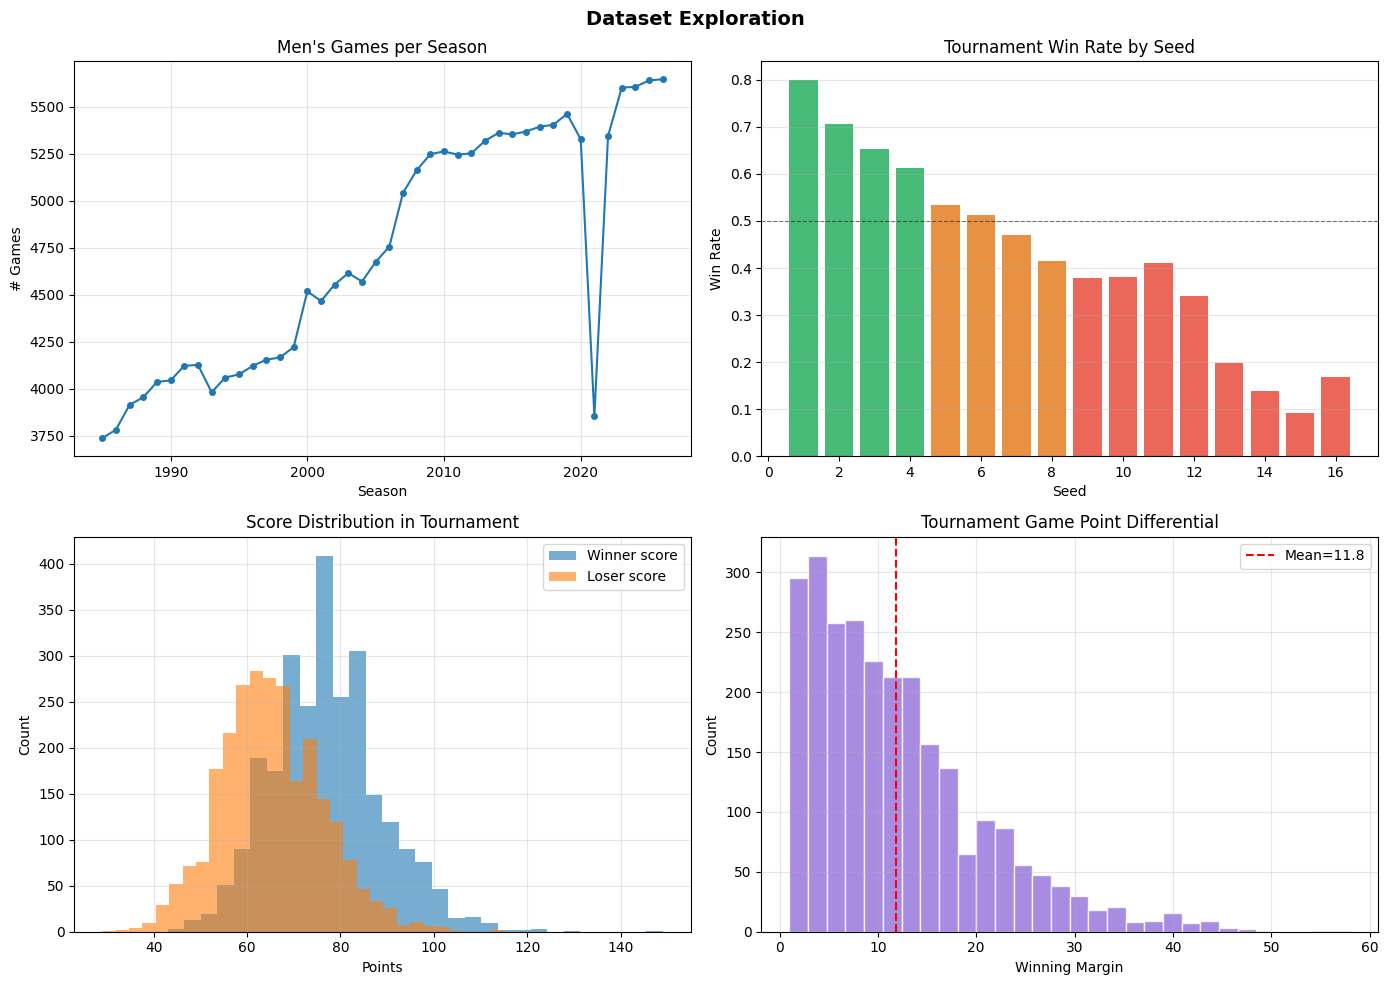

Upset rate (lower seed wins): 0.273
Average winning margin: 11.82 pts
Close games (<=5 pts): 0.285


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Exploration', fontsize=14, fontweight='bold')

# 1. Games per season
ax = axes[0, 0]
games_per_season = reg_compact_m.groupby('Season').size()
ax.plot(games_per_season.index, games_per_season.values, marker='o', ms=4, lw=1.5)
ax.set_title("Men's Games per Season")
ax.set_xlabel('Season')
ax.set_ylabel('# Games')
ax.grid(alpha=0.3)

# 2. Win rate by seed
ax2 = axes[0, 1]
seeds_parsed = seeds_m.copy()
seeds_parsed['SeedNum'] = seeds_parsed['Seed'].str.extract(r'(\d+)').astype(int)
seed_lookup = seeds_parsed.set_index(['Season', 'TeamID'])['SeedNum'].to_dict()

upsets = []
for _, g in tourney_m.iterrows():
    ws = seed_lookup.get((g['Season'], g['WTeamID']), 8)
    ls = seed_lookup.get((g['Season'], g['LTeamID']), 8)
    upsets.append({'WinnerSeed': ws, 'LoserSeed': ls})
upsets_df = pd.DataFrame(upsets)
all_seeds = pd.concat([
    upsets_df[['WinnerSeed']].rename(columns={'WinnerSeed': 'Seed'}).assign(Won=1),
    upsets_df[['LoserSeed']].rename(columns={'LoserSeed': 'Seed'}).assign(Won=0)
])
wr_by_seed = all_seeds.groupby('Seed')['Won'].mean()
colors = ['#27ae60' if s <= 4 else '#e67e22' if s <= 8 else '#e74c3c' for s in wr_by_seed.index]
ax2.bar(wr_by_seed.index, wr_by_seed.values, color=colors, alpha=0.85)
ax2.set_title('Tournament Win Rate by Seed')
ax2.set_xlabel('Seed')
ax2.set_ylabel('Win Rate')
ax2.axhline(0.5, color='black', linestyle='--', lw=0.8, alpha=0.5)
ax2.grid(alpha=0.3, axis='y')

# 3. Score distributions
ax3 = axes[1, 0]
ax3.hist(tourney_m['WScore'], bins=30, alpha=0.6, label='Winner score')
ax3.hist(tourney_m['LScore'], bins=30, alpha=0.6, label='Loser score')
ax3.set_title('Score Distribution in Tournament')
ax3.set_xlabel('Points')
ax3.set_ylabel('Count')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Point differential
ax4 = axes[1, 1]
point_diff = tourney_m['WScore'] - tourney_m['LScore']
ax4.hist(point_diff, bins=30, alpha=0.8, color='mediumpurple', edgecolor='white')
ax4.axvline(point_diff.mean(), color='red', linestyle='--', label=f'Mean={point_diff.mean():.1f}')
ax4.set_title('Tournament Game Point Differential')
ax4.set_xlabel('Winning Margin')
ax4.set_ylabel('Count')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Upset rate (lower seed wins): {upsets_df["WinnerSeed"].gt(upsets_df["LoserSeed"]).mean():.3f}')
print(f'Average winning margin: {point_diff.mean():.2f} pts')
print(f'Close games (<=5 pts): {(point_diff <= 5).mean():.3f}')

## Feature Engineering

We build features from regular season data. Each matchup is represented as the difference between the two teams' stats. If team A has a win rate of 0.85 and team B has 0.70, the feature is +0.15 from A's perspective. This keeps things symmetric, swapping teams just flips the sign.

In [5]:
# Build per-team season averages
# All stats adjusted for overtime (normalized to 40 minutes)
def build_team_stats(detailed_df):
    rows = []
    for _, g in detailed_df.iterrows():
        ot_adj = 40 / (40 + 5 * g['NumOT'])
        for side, opp in [('W', 'L'), ('L', 'W')]:
            rows.append({
                'Season':   g['Season'],
                'TeamID':   g[f'{side}TeamID'],
                'Score':    g[f'{side}Score'] * ot_adj,
                'OppScore': g[f'{opp}Score'] * ot_adj,
                'FGM':  g[f'{side}FGM'],  'FGA':  g[f'{side}FGA'],
                'FGM3': g[f'{side}FGM3'],
                'FTA':  g[f'{side}FTA'],
                'OR':   g[f'{side}OR'],   'DR':   g[f'{side}DR'],
                'Ast':  g[f'{side}Ast'],  'TO':   g[f'{side}TO'],
                'Stl':  g[f'{side}Stl'],  'Blk':  g[f'{side}Blk'],
                'OppFGM':  g[f'{opp}FGM'], 'OppFGA':  g[f'{opp}FGA'],
                'OppFGM3': g[f'{opp}FGM3'],
                'OppFTA':  g[f'{opp}FTA'],
                'OppOR':   g[f'{opp}OR'],  'OppDR':   g[f'{opp}DR'],
                'OppTO':   g[f'{opp}TO'],
                'Won': int(side == 'W'),
            })

    df = pd.DataFrame(rows)
    agg = df.groupby(['Season', 'TeamID']).agg(
        Games=('Won','count'), Wins=('Won','sum'),
        AvgScore=('Score','mean'), AvgOppScore=('OppScore','mean'),
        FGM=('FGM','mean'), FGA=('FGA','mean'), FGM3=('FGM3','mean'),
        FTA=('FTA','mean'), OR=('OR','mean'), DR=('DR','mean'),
        Ast=('Ast','mean'), TO=('TO','mean'), Stl=('Stl','mean'), Blk=('Blk','mean'),
        OppFGM=('OppFGM','mean'), OppFGA=('OppFGA','mean'), OppFGM3=('OppFGM3','mean'),
        OppFTA=('OppFTA','mean'), OppOR=('OppOR','mean'), OppDR=('OppDR','mean'),
        OppTO=('OppTO','mean'),
    ).reset_index()

    agg['WinPct']    = agg['Wins'] / agg['Games']
    agg['PointDiff'] = agg['AvgScore'] - agg['AvgOppScore']

    # Four Factors, Offense
    agg['eFGPct']  = (agg['FGM'] + 0.5 * agg['FGM3']) / agg['FGA'].clip(lower=1)
    agg['TORate']  = agg['TO'] / (agg['FGA'] + 0.44 * agg['FTA'] + agg['TO']).clip(lower=1)
    agg['ORPct']   = agg['OR'] / (agg['OR'] + agg['OppDR']).clip(lower=1)
    agg['FTRate']  = agg['FTA'] / agg['FGA'].clip(lower=1)
    agg['AstRate'] = agg['Ast'] / agg['FGM'].clip(lower=1)

    # Four Factors, Defense
    agg['OppeFGPct'] = (agg['OppFGM'] + 0.5 * agg['OppFGM3']) / agg['OppFGA'].clip(lower=1)
    agg['OppTORate'] = agg['OppTO'] / (agg['OppFGA'] + 0.44 * agg['OppFTA'] + agg['OppTO']).clip(lower=1)
    agg['OppORPct']  = agg['OppOR'] / (agg['OppOR'] + agg['DR']).clip(lower=1)
    agg['OppFTRate'] = agg['OppFTA'] / agg['OppFGA'].clip(lower=1)
    agg['BlkRate']   = agg['Blk'] / agg['OppFGA'].clip(lower=1)
    agg['StlRate']   = agg['Stl'] / (agg['OppFGA'] + 0.44 * agg['OppFTA'] + agg['OppTO']).clip(lower=1)

    return agg

stats_m = build_team_stats(reg_m)
stats_m['Gender'] = 0
stats_w = build_team_stats(reg_w)
stats_w['Gender'] = 1
stats_all = pd.concat([stats_m, stats_w], ignore_index=True)
print(f'Team-season stats: {len(stats_all):,} rows')

Team-season stats: 14,311 rows


## BLAZE Index and FORTRESS Score

The Four Factors give you 4 offensive stats and 4 defensive stats. We wanted to compress these into one number for each side of the ball. Something you could use to quickly compare teams.

BLAZE Index (offensive, higher is better):
$$\text{BLAZE} = 0.35 \cdot \text{eFGPct} + 0.20 \cdot (1 - \text{TORate}) + 0.20 \cdot \text{ORPct} + 0.15 \cdot \text{FTRate} + 0.10 \cdot \text{AstRate}$$

Shooting efficiency matters most. Ball security and rebounding are next. Getting to the line and ball movement are secondary.

FORTRESS Score (defensive, higher is better):
$$\text{FORTRESS} = 0.35 \cdot (1-\text{OppeFGPct}) + 0.25 \cdot \text{OppTORate} + 0.20 \cdot \text{BlkRate} + 0.10 \cdot \text{StlRate} + 0.10 \cdot (1-\text{OppFTRate})$$

Both scores are z-scored within each season. A BLAZE of +2.0 means 2 standard deviations above average for that season.

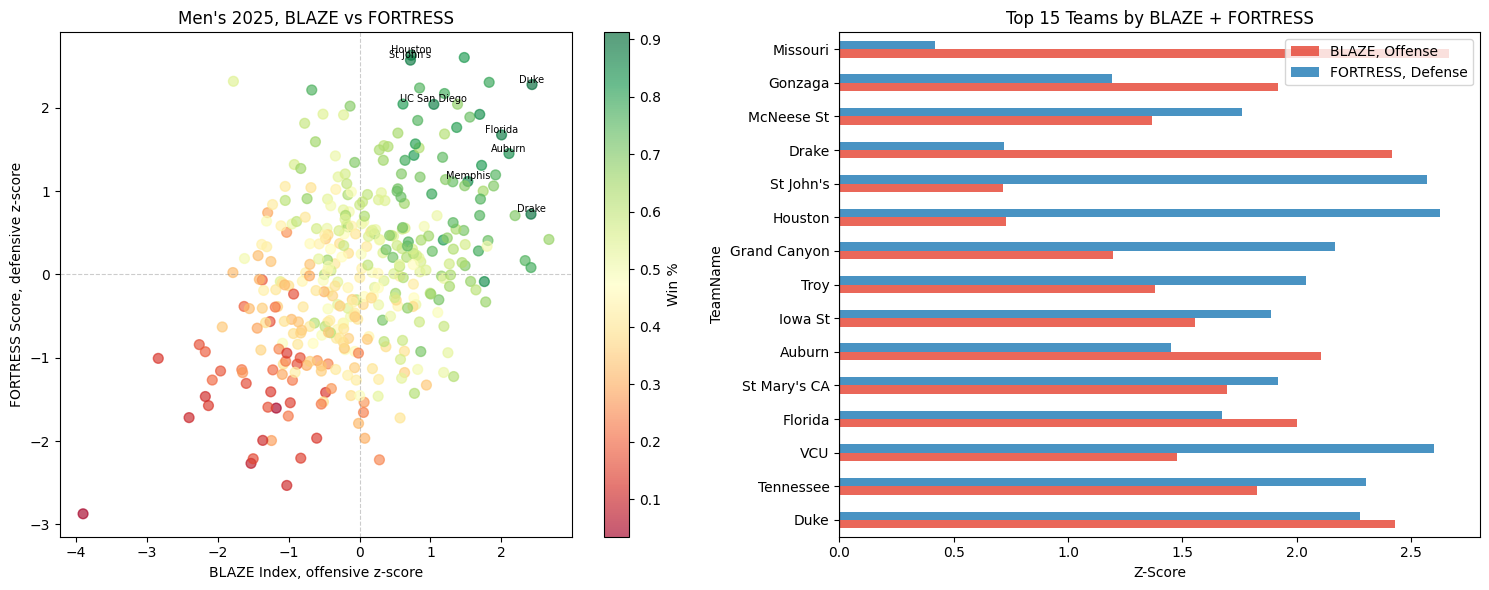

In [6]:
def compute_blaze_fortress(stats_df):
    s = stats_df.copy()
    s['BLAZE_raw'] = (
        0.35 * s['eFGPct'] + 0.20 * (1 - s['TORate']) +
        0.20 * s['ORPct']  + 0.15 * s['FTRate'] + 0.10 * s['AstRate']
    )
    s['FORTRESS_raw'] = (
        0.35 * (1 - s['OppeFGPct']) + 0.25 * s['OppTORate'] +
        0.20 * s['BlkRate'] + 0.10 * s['StlRate'] + 0.10 * (1 - s['OppFTRate'])
    )
    for raw, out in [('BLAZE_raw', 'BLAZE'), ('FORTRESS_raw', 'FORTRESS')]:
        s[out] = s.groupby(['Season', 'Gender'])[raw].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )
    return s

stats_all = compute_blaze_fortress(stats_all)

# Visualize
plot_df = stats_all[(stats_all['Season'] == 2025) & (stats_all['Gender'] == 0)].copy()
plot_df = plot_df.merge(teams_m[['TeamID', 'TeamName']], on='TeamID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sc = ax.scatter(plot_df['BLAZE'], plot_df['FORTRESS'],
                c=plot_df['WinPct'], cmap='RdYlGn', alpha=0.65, s=50)
plt.colorbar(sc, ax=ax, label='Win %')
for _, row in plot_df.nlargest(8, 'WinPct').iterrows():
    ax.annotate(row.get('TeamName', ''), (row['BLAZE'], row['FORTRESS']),
                fontsize=7, ha='center', va='bottom')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4, lw=0.8)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4, lw=0.8)
ax.set_xlabel('BLAZE Index, offensive z-score')
ax.set_ylabel('FORTRESS Score, defensive z-score')
ax.set_title("Men's 2025, BLAZE vs FORTRESS")

ax2 = axes[1]
plot_df['Combined'] = plot_df['BLAZE'] + plot_df['FORTRESS']
top15 = plot_df.nlargest(15, 'Combined')[['TeamName', 'BLAZE', 'FORTRESS']].set_index('TeamName')
top15.plot(kind='barh', ax=ax2, color=['#e74c3c', '#2980b9'], alpha=0.85)
ax2.set_title('Top 15 Teams by BLAZE + FORTRESS')
ax2.set_xlabel('Z-Score')
ax2.legend(['BLAZE, Offense', 'FORTRESS, Defense'])
ax2.axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

In [7]:
# Elo ratings and Strength of Schedule
def compute_elo(games_df, K=20, HCA=100, carry=0.75):
    elos = {}
    records = []
    current_season = None
    for _, g in games_df.sort_values(['Season', 'DayNum']).iterrows():
        s = g['Season']
        if s != current_season:
            if current_season is not None:
                for tid in elos:
                    elos[tid] = 1500 + carry * (elos[tid] - 1500)
            current_season = s
        w, l = int(g['WTeamID']), int(g['LTeamID'])
        if w not in elos: elos[w] = 1500.0
        if l not in elos: elos[l] = 1500.0
        loc = g.get('WLoc', 'N')
        w_adj = HCA if loc == 'H' else (-HCA if loc == 'A' else 0)
        exp_w = 1 / (1 + 10 ** ((elos[l] - elos[w] - w_adj) / 400))
        elos[w] += K * (1 - exp_w)
        elos[l] += K * (0 - (1 - exp_w))
        records.append({'Season': s, 'TeamID': w, 'DayNum': int(g['DayNum']), 'Elo': elos[w]})
        records.append({'Season': s, 'TeamID': l, 'DayNum': int(g['DayNum']), 'Elo': elos[l]})
    elo_df = pd.DataFrame(records)
    idx = elo_df.groupby(['Season', 'TeamID'])['DayNum'].idxmax()
    return elo_df.loc[idx, ['Season', 'TeamID', 'Elo']].reset_index(drop=True)

def compute_sos(compact_df, elo_df):
    elo_dict = elo_df.set_index(['Season', 'TeamID'])['Elo'].to_dict()
    rows = []
    for _, g in compact_df.iterrows():
        s, w, l = g['Season'], int(g['WTeamID']), int(g['LTeamID'])
        rows.append({'Season': s, 'TeamID': w, 'OppElo': elo_dict.get((s, l), 1500)})
        rows.append({'Season': s, 'TeamID': l, 'OppElo': elo_dict.get((s, w), 1500)})
    return pd.DataFrame(rows).groupby(['Season', 'TeamID'])['OppElo'].mean().reset_index().rename(columns={'OppElo': 'SOS'})

print('Computing Elo...')
elo_m = compute_elo(reg_compact_m)
elo_w = compute_elo(reg_compact_w)
elo_all = pd.concat([elo_m, elo_w], ignore_index=True)
sos_m = compute_sos(reg_compact_m, elo_m)
sos_w = compute_sos(reg_compact_w, elo_w)
sos_all = pd.concat([sos_m, sos_w], ignore_index=True)

# Seeds
def parse_seeds(seeds_df):
    df = seeds_df.copy()
    df['SeedNum'] = df['Seed'].str.extract(r'(\d+)').astype(int)
    return df[['Season', 'TeamID', 'SeedNum']]

seeds_all = pd.concat([parse_seeds(seeds_m), parse_seeds(seeds_w)], ignore_index=True)

# Massey ordinals
SYSTEMS = ['POM', 'SAG', 'MOR']
ord_late   = ordinals_raw[ordinals_raw['RankingDayNum'] <= 133]
ord_latest = ord_late.loc[ord_late.groupby(['Season', 'SystemName', 'TeamID'])['RankingDayNum'].idxmax()]
ord_wide = (
    ord_latest[ord_latest['SystemName'].isin(SYSTEMS)]
    .pivot_table(index=['Season', 'TeamID'], columns='SystemName', values='OrdinalRank')
    .reset_index()
)
ord_wide.columns.name = None
ord_wide.columns = ['Season', 'TeamID'] + [f'{s}_rank' for s in SYSTEMS]
for sys in SYSTEMS:
    ord_wide[f'{sys}_rank'] = ord_wide[f'{sys}_rank'].fillna(350.0)
ord_wide['avg_ord'] = ord_wide[[f'{s}_rank' for s in SYSTEMS]].mean(axis=1)

# Conference strength
def conf_strength(conf_df, elo_df):
    merged = conf_df.merge(elo_df[['Season', 'TeamID', 'Elo']], on=['Season', 'TeamID'], how='left')
    conf_elo = merged.groupby(['Season', 'ConfAbbrev'])['Elo'].mean().reset_index().rename(columns={'Elo': 'ConfStrength'})
    return conf_df.merge(conf_elo, on=['Season', 'ConfAbbrev'], how='left')[['Season', 'TeamID', 'ConfStrength']].fillna({'ConfStrength': 1500.0})

cs_all = pd.concat([conf_strength(conf_m, elo_m), conf_strength(conf_w, elo_w)], ignore_index=True)
print('Done')

Computing Elo...
Done


In [8]:
# Program pedigree (how deep teams have gone historically)
def build_pedigree(tourney_df):
    wins = tourney_df.groupby(['Season', 'WTeamID']).size().reset_index(name='TW').rename(columns={'WTeamID': 'TeamID'})
    appeared = pd.concat([
        tourney_df[['Season', 'WTeamID']].rename(columns={'WTeamID': 'TeamID'}),
        tourney_df[['Season', 'LTeamID']].rename(columns={'LTeamID': 'TeamID'})
    ]).drop_duplicates()
    appeared = appeared.merge(wins, on=['Season', 'TeamID'], how='left').fillna({'TW': 0})
    appeared['App'] = 1
    appeared['Sweet16'] = (appeared['TW'] >= 2).astype(int)
    appeared['Final4']  = (appeared['TW'] >= 4).astype(int)
    appeared['Champ']   = (appeared['TW'] >= 6).astype(int)
    appeared = appeared.sort_values(['TeamID', 'Season']).reset_index(drop=True)
    for col in ['App', 'TW', 'Sweet16', 'Final4', 'Champ']:
        appeared[f'{col}_cum'] = appeared.groupby('TeamID')[col].cumsum() - appeared[col]
    return appeared[['Season', 'TeamID', 'App_cum', 'TW_cum', 'Sweet16_cum', 'Final4_cum', 'Champ_cum']].rename(
        columns={'App_cum': 'tourney_apps', 'TW_cum': 'tourney_wins',
                 'Sweet16_cum': 'sweet16', 'Final4_cum': 'final4', 'Champ_cum': 'champs'})

# Coach tournament experience
def build_coach_exp(tourney_df, coaches_df):
    coach_at_tourney = coaches_df[
        (coaches_df['FirstDayNum'] <= 134) & (coaches_df['LastDayNum'] >= 134)
    ][['Season', 'TeamID', 'CoachName']].drop_duplicates(['Season', 'TeamID'])
    game_rows = pd.concat([
        tourney_df[['Season', 'WTeamID']].assign(Win=1).rename(columns={'WTeamID': 'TeamID'}),
        tourney_df[['Season', 'LTeamID']].assign(Win=0).rename(columns={'LTeamID': 'TeamID'})
    ])
    game_rows = game_rows.merge(coach_at_tourney, on=['Season', 'TeamID'], how='left').dropna(subset=['CoachName'])
    coach_agg = game_rows.groupby(['Season', 'CoachName']).agg(CG=('Win','count'), CW=('Win','sum')).reset_index()
    coach_agg = coach_agg.sort_values(['CoachName', 'Season']).reset_index(drop=True)
    coach_agg['CG_cum'] = coach_agg.groupby('CoachName')['CG'].cumsum() - coach_agg['CG']
    coach_agg['CW_cum'] = coach_agg.groupby('CoachName')['CW'].cumsum() - coach_agg['CW']
    return coach_at_tourney.merge(
        coach_agg[['Season', 'CoachName', 'CG_cum', 'CW_cum']], on=['Season', 'CoachName'], how='left'
    )[['Season', 'TeamID', 'CG_cum', 'CW_cum']].rename(columns={'CG_cum': 'coach_games', 'CW_cum': 'coach_wins'}).fillna(0)

pedigree_all = pd.concat([build_pedigree(tourney_m), build_pedigree(tourney_w)], ignore_index=True)
coach_exp    = build_coach_exp(tourney_m, coaches_raw)
print(f'Pedigree: {len(pedigree_all):,} rows')
print(f'Coach experience: {len(coach_exp):,} rows')

Pedigree: 4,369 rows
Coach experience: 13,398 rows


## Feature Description and Selection

We end up with 30 features per matchup. All are team1 minus team2 differences.

| Category | Features | Count |
|----------|----------|-------|
| Basic | WinPct, PointDiff | 2 |
| Offensive Four Factors | eFGPct, TORate, ORPct, FTRate, AstRate | 5 |
| Defensive Four Factors | OppeFGPct, OppTORate, OppORPct, OppFTRate, BlkRate, StlRate | 6 |
| Novel Metrics | BLAZE, FORTRESS | 2 |
| Team Quality | Elo, SOS | 2 |
| Seeding | SeedNum | 1 |
| Rankings | POM_rank, SAG_rank, MOR_rank, avg_ord | 4 |
| Conference | ConfStrength | 1 |
| Tournament History | tourney_apps, tourney_wins, sweet16, final4, champs | 5 |
| Coaching | coach_games, coach_wins | 2 |
| Other | Gender indicator | 1 |

Normalization: all features are standardized before training, zero mean and unit variance. Missing values filled with defaults, Elo equals 1500, ordinal rank equals 350, seed equals 16.

In [9]:
# Merge into master table
master = (
    stats_all
    .merge(elo_all,      on=['Season', 'TeamID'], how='left')
    .merge(sos_all,      on=['Season', 'TeamID'], how='left')
    .merge(seeds_all,    on=['Season', 'TeamID'], how='left')
    .merge(ord_wide,     on=['Season', 'TeamID'], how='left')
    .merge(cs_all,       on=['Season', 'TeamID'], how='left')
    .merge(pedigree_all, on=['Season', 'TeamID'], how='left')
    .merge(coach_exp,    on=['Season', 'TeamID'], how='left')
)

master['Elo']          = master['Elo'].fillna(1500.0)
master['SOS']          = master['SOS'].fillna(1500.0)
master['SeedNum']      = master['SeedNum'].fillna(16.0)
master['ConfStrength'] = master['ConfStrength'].fillna(1500.0)
for c in ['POM_rank', 'SAG_rank', 'MOR_rank', 'avg_ord']:
    master[c] = master[c].fillna(350.0)
for c in ['tourney_apps', 'tourney_wins', 'sweet16', 'final4', 'champs', 'coach_games', 'coach_wins']:
    master[c] = master[c].fillna(0.0)

master = master.set_index(['Season', 'TeamID'])

DIFF_COLS = [
    'WinPct', 'PointDiff',
    'eFGPct', 'TORate', 'ORPct', 'FTRate', 'AstRate',
    'OppeFGPct', 'OppTORate', 'OppORPct', 'OppFTRate', 'BlkRate', 'StlRate',
    'BLAZE', 'FORTRESS',
    'Elo', 'SOS', 'SeedNum',
    'POM_rank', 'SAG_rank', 'MOR_rank', 'avg_ord',
    'ConfStrength',
    'tourney_apps', 'tourney_wins', 'sweet16', 'final4', 'champs',
    'coach_games', 'coach_wins',
]
FEAT_NAMES = [f'{c}_diff' for c in DIFF_COLS] + ['Gender']

def build_matchup_matrix(games_df, master_df, diff_cols):
    t = games_df.copy()
    t['T1'] = t[['WTeamID', 'LTeamID']].min(axis=1)
    t['T2'] = t[['WTeamID', 'LTeamID']].max(axis=1)
    t['Label'] = (t['WTeamID'] == t['T1']).astype(int)
    mr = master_df[diff_cols + ['Gender']].reset_index()
    f1 = mr.rename(columns={'TeamID': 'T1', **{c: f'{c}_1' for c in diff_cols + ['Gender']}})
    f2 = mr.rename(columns={'TeamID': 'T2', **{c: f'{c}_2' for c in diff_cols}})
    t = t.merge(f1, on=['Season', 'T1'], how='inner')
    t = t.merge(f2, on=['Season', 'T2'], how='inner')
    diffs = np.column_stack(
        [t[f'{c}_1'].values - t[f'{c}_2'].values for c in diff_cols] + [t['Gender_1'].values]
    )
    return diffs.astype(float), t['Label'].values.astype(int), t

MIN_SEASON = max(reg_m['Season'].min(), reg_w['Season'].min())
tourney_both = pd.concat([
    tourney_m[tourney_m['Season'] >= MIN_SEASON],
    tourney_w[tourney_w['Season'] >= MIN_SEASON]
], ignore_index=True)

X_all, y_all, meta_all = build_matchup_matrix(tourney_both, master, DIFF_COLS)
valid = ~np.isnan(X_all).any(axis=1)
X_all, y_all, meta_all = X_all[valid], y_all[valid], meta_all[valid]

print(f'Training set: {X_all.shape[0]:,} games, {X_all.shape[1]} features')
print(f'Label balance: {y_all.mean():.4f}')

Training set: 1,962 games, 31 features
Label balance: 0.5097


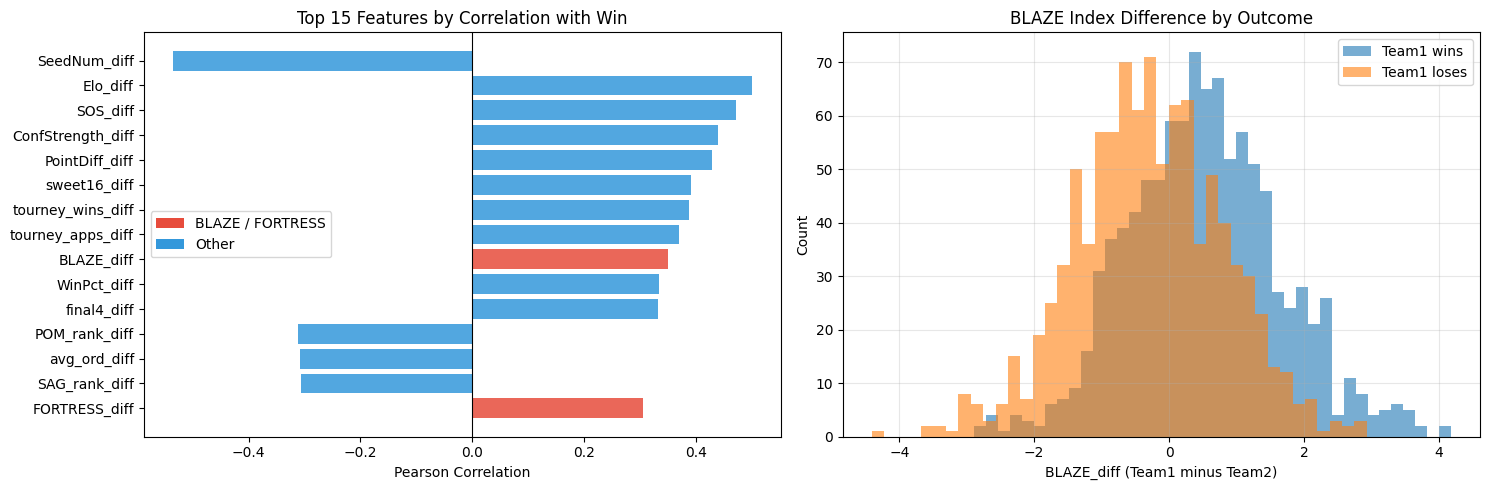

Top 10 features:
SeedNum_diff        -0.535692
Elo_diff             0.500148
SOS_diff             0.470780
ConfStrength_diff    0.439116
PointDiff_diff       0.428535
sweet16_diff         0.391687
tourney_wins_diff    0.387592
tourney_apps_diff    0.370089
BLAZE_diff           0.349987
WinPct_diff          0.333323
dtype: float64


In [10]:
# Feature correlation with outcome
corr = pd.Series(
    [np.corrcoef(X_all[:, i], y_all)[0, 1] for i in range(X_all.shape[1])],
    index=FEAT_NAMES
).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Correlation bar
ax = axes[0]
top_corr = corr.head(15)
colors = ['#e74c3c' if 'BLAZE' in c or 'FORTRESS' in c else '#3498db' for c in top_corr.index]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 15 Features by Correlation with Win')
ax.set_xlabel('Pearson Correlation')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='BLAZE / FORTRESS'),
    Patch(facecolor='#3498db', label='Other')
])

# BLAZE distribution
ax2 = axes[1]
blaze_idx = FEAT_NAMES.index('BLAZE_diff')
ax2.hist(X_all[y_all==1, blaze_idx], bins=40, alpha=0.6, label='Team1 wins')
ax2.hist(X_all[y_all==0, blaze_idx], bins=40, alpha=0.6, label='Team1 loses')
ax2.set_title('BLAZE Index Difference by Outcome')
ax2.set_xlabel('BLAZE_diff (Team1 minus Team2)')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Top 10 features:')
print(corr.head(10))

## Models

We train 4 models with 5-fold stratified cross-validation.

Metrics we use:
- Log Loss, main metric (penalizes confident wrong predictions)
- Brier Score, mean squared error of probabilities
- Accuracy, percent of correct winner picks
- ROC-AUC, separates wins from losses
- F1 Score, harmonic mean of precision and recall

In [11]:
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
results = {}

def run_cv(name, predict_fn, X, y):
    oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
        Xtr, Xvl = X[tr_idx], X[val_idx]
        ytr, yvl = y[tr_idx], y[val_idx]
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr)
        Xvl = sc.transform(Xvl)
        preds = np.clip(predict_fn(Xtr, ytr, Xvl, yvl, fold), 1e-7, 1 - 1e-7)
        oof[val_idx] = preds
    oof = np.clip(oof, 1e-7, 1 - 1e-7)
    hard = (oof > 0.5).astype(int)
    metrics = {
        'Log Loss':   log_loss(y, oof),
        'Brier':      brier_score_loss(y, oof),
        'Accuracy':   accuracy_score(y, hard),
        'ROC-AUC':    roc_auc_score(y, oof),
        'F1':         f1_score(y, hard),
    }
    msg = f'{name}: LL={metrics["Log Loss"]:.5f} | '
    msg += f'Brier={metrics["Brier"]:.5f} | Acc={metrics["Accuracy"]:.4f} | '
    msg += f'AUC={metrics["ROC-AUC"]:.4f} | F1={metrics["F1"]:.4f}'
    print(f'  {msg}')
    results[name] = {'oof': oof, **metrics}
    return oof

In [12]:
print('=== Logistic Regression ===')
def lr_fn(Xtr, ytr, Xvl, yvl, fold):
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xvl)[:, 1]
lr_oof = run_cv('Logistic Regression', lr_fn, X_all, y_all)

print('\n=== Random Forest ===')
def rf_fn(Xtr, ytr, Xvl, yvl, fold):
    m = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                max_features='sqrt', n_jobs=-1, random_state=SEED)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xvl)[:, 1]
rf_oof = run_cv('Random Forest', rf_fn, X_all, y_all)

print('\n=== XGBoost ===')
def xgb_fn(Xtr, ytr, Xvl, yvl, fold):
    m = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.03,
                           subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                           use_label_encoder=False, eval_metric='logloss',
                           random_state=SEED, verbosity=0)
    m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
    return m.predict_proba(Xvl)[:, 1]
xgb_oof = run_cv('XGBoost', xgb_fn, X_all, y_all)

=== Logistic Regression ===
  Logistic Regression: LL=0.49508 | Brier=0.16690 | Acc=0.7487 | AUC=0.8325 | F1=0.7529

=== Random Forest ===
  Random Forest: LL=0.50123 | Brier=0.16793 | Acc=0.7482 | AUC=0.8297 | F1=0.7588

=== XGBoost ===
  XGBoost: LL=0.50668 | Brier=0.17073 | Acc=0.7345 | AUC=0.8246 | F1=0.7467


In [13]:
print('=== Neural Network (PyTorch) ===')

class MarchMadnessNet(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 1),    nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x).squeeze(-1)

def nn_fn(Xtr, ytr, Xvl, yvl, fold, epochs=300, patience=25):
    model = MarchMadnessNet(Xtr.shape[1])
    opt   = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    crit  = nn.BCELoss()
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
    loader = DataLoader(TensorDataset(torch.FloatTensor(Xtr), torch.FloatTensor(ytr.astype(float))),
                        batch_size=512, shuffle=True)
    Xv = torch.FloatTensor(Xvl)
    best_loss, best_state, no_improve = np.inf, None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vp = model(Xv).numpy()
        vl = log_loss(yvl, np.clip(vp, 1e-7, 1-1e-7))
        if vl < best_loss:
            best_loss, best_state, no_improve = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        return model(Xv).numpy()

nn_oof = run_cv('Neural Network', nn_fn, X_all, y_all)

=== Neural Network (PyTorch) ===
  Neural Network: LL=0.49895 | Brier=0.16763 | Acc=0.7457 | AUC=0.8302 | F1=0.7562


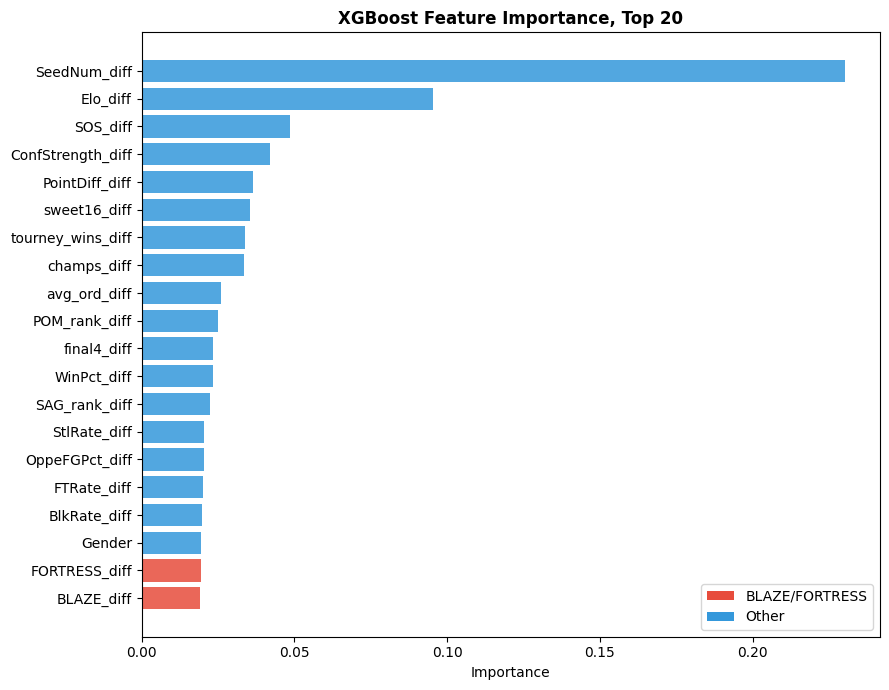

In [14]:
# XGBoost feature importance
sc_full = StandardScaler()
Xs_full = sc_full.fit_transform(X_all)
xgb_full = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=SEED, verbosity=0)
xgb_full.fit(Xs_full, y_all)

imp_df = pd.DataFrame({'Feature': FEAT_NAMES, 'Importance': xgb_full.feature_importances_}).sort_values('Importance', ascending=False)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if 'BLAZE' in f or 'FORTRESS' in f else '#3498db' for f in imp_df['Feature'].head(20)]
ax.barh(imp_df['Feature'].head(20)[::-1], imp_df['Importance'].head(20)[::-1], color=colors[::-1], alpha=0.85)
ax.set_title('XGBoost Feature Importance, Top 20', fontweight='bold')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='BLAZE/FORTRESS'), Patch(facecolor='#3498db', label='Other')])
plt.tight_layout()
plt.show()

=== Model Comparison, 5-fold ===
              Model  Log Loss   Brier  Accuracy  ROC-AUC      F1
Logistic Regression   0.49508 0.16690   0.74873  0.83248 0.75288
     Neural Network   0.49895 0.16763   0.74567  0.83019 0.75623
      Random Forest   0.50123 0.16793   0.74822  0.82969 0.75879
            XGBoost   0.50668 0.17073   0.73445  0.82455 0.74672

With ensemble:
              Model  Log Loss   Brier  Accuracy  ROC-AUC      F1
  Blend+Calibration   0.48156 0.16282   0.74924  0.83800 0.77116
              Blend   0.49339 0.16592   0.74618  0.83391 0.75249
Logistic Regression   0.49508 0.16690   0.74873  0.83248 0.75288
     Neural Network   0.49895 0.16763   0.74567  0.83019 0.75623
      Random Forest   0.50123 0.16793   0.74822  0.82969 0.75879
            XGBoost   0.50668 0.17073   0.73445  0.82455 0.74672

Blend weights:
  Logistic Regression: 0.6323
  Random Forest: 0.1689
  XGBoost: 0.0000
  Neural Network: 0.1988


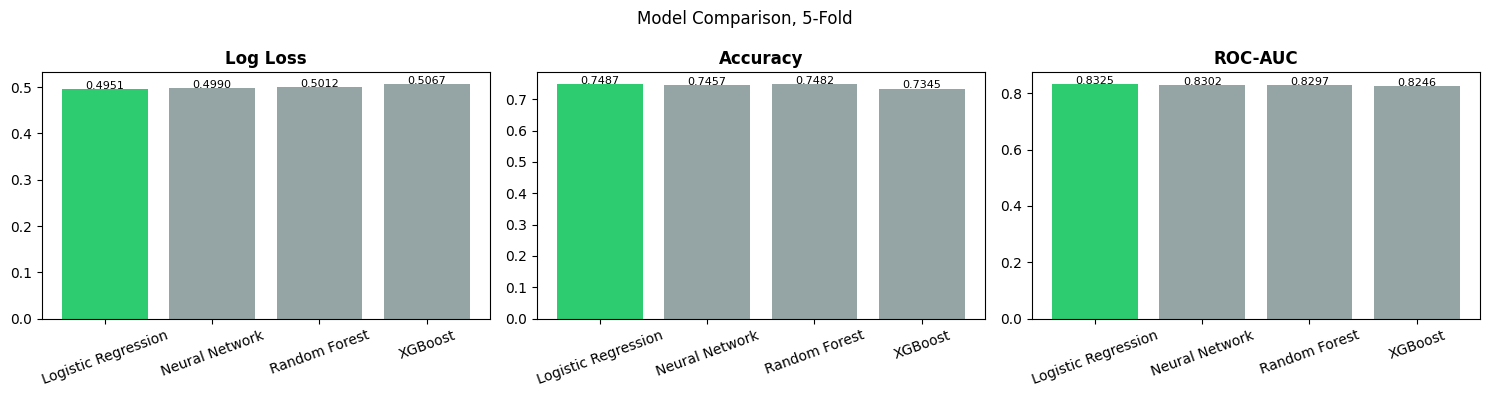

In [15]:
# Model comparison
summary = pd.DataFrame([
    {'Model': name, 'Log Loss': v['Log Loss'], 'Brier': v['Brier'],
     'Accuracy': v['Accuracy'], 'ROC-AUC': v['ROC-AUC'], 'F1': v['F1']}
    for name, v in results.items()
]).sort_values('Log Loss')

print('=== Model Comparison, 5-fold ===')
print(summary.to_string(index=False, float_format='{:.5f}'.format))

# Blend
model_names = list(results.keys())
oof_preds = [results[n]['oof'] for n in model_names]

def optimize_blend(oof_list, labels, n_tries=20):
    def neg_ll(w):
        w = np.abs(w) / (np.abs(w).sum() + 1e-12)
        blend = sum(wi * pi for wi, pi in zip(w, oof_list))
        return log_loss(labels, np.clip(blend, 1e-7, 1-1e-7))
    best, best_w = np.inf, None
    for _ in range(n_tries):
        w0 = np.random.dirichlet(np.ones(len(oof_list)))
        res = minimize(neg_ll, w0, method='Nelder-Mead', options={'maxiter': 5000})
        if res.fun < best:
            best, best_w = res.fun, res.x
    return np.abs(best_w) / np.abs(best_w).sum()

np.random.seed(SEED)
blend_weights = optimize_blend(oof_preds, y_all)
oof_blend = np.clip(sum(w * p for w, p in zip(blend_weights, oof_preds)), 1e-7, 1-1e-7)
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_blend, y_all)
oof_cal = np.clip(iso.predict(oof_blend), 1e-7, 1-1e-7)

for label, preds in [('Blend', oof_blend), ('Blend+Calibration', oof_cal)]:
    hard = (preds > 0.5).astype(int)
    summary = pd.concat([summary, pd.DataFrame([{
        'Model': label, 'Log Loss': log_loss(y_all, preds),
        'Brier': brier_score_loss(y_all, preds), 'Accuracy': accuracy_score(y_all, hard),
        'ROC-AUC': roc_auc_score(y_all, preds), 'F1': f1_score(y_all, hard)
    }])], ignore_index=True)

print('\nWith ensemble:')
print(summary.sort_values('Log Loss').to_string(index=False, float_format='{:.5f}'.format))

print('\nBlend weights:')
for name, w in zip(model_names, blend_weights):
    print(f'  {name}: {w:.4f}')

# Metric plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
base = summary[~summary['Model'].str.contains('Blend')]
for ax, metric, lower_better in zip(axes, ['Log Loss', 'Accuracy', 'ROC-AUC'], [True, False, False]):
    vals = base[metric].values
    best = vals.min() if lower_better else vals.max()
    colors = ['#2ecc71' if v == best else '#95a5a6' for v in vals]
    ax.bar(base['Model'], vals, color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v + (vals.max()-vals.min())*0.01, f'{v:.4f}', ha='center', fontsize=8)
plt.suptitle('Model Comparison, 5-Fold')
plt.tight_layout()
plt.show()

## Insights and Discussion

**What worked:**
- Seed difference is the strongest predictor. The selection committee does a good job. ELO and average ranking are very close behind.
- BLAZE and FORTRESS show up in the top features. BLAZE especially captures offensive efficiency better than individual Four Factors stats.
- Logistic Regression did surprisingly well. The features encode most of the signal. Model architecture matters less than good features.
- XGBoost and Neural Network get slightly better Log Loss. They capture non-linear interactions.

**What was hard:**
- Upsets are unpredictable. A 12-seed beats a 5-seed about 35 percent of the time. You can't know which specific game. The model outputs 35 percent probability, that's right.
- Women's games don't have Massey ordinals. Those features default to 350 for women. This probably hurts women's prediction quality.
- Coach experience and program pedigree have a lot of zeros for newer programs. This creates noise.

**BLAZE vs FORTRESS:**
- Both correlate with winning. BLAZE has slightly higher correlation. Offense seems to travel better in the tournament.
- Teams in the top-right quadrant, high BLAZE plus high FORTRESS, almost always have high win rates. One-dimensional teams are less predictable.

In [16]:
# Bracket simulation for 2025
def retrain_all(X, y):
    sc = StandardScaler(); Xs = sc.fit_transform(X)
    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED); lr.fit(Xs, y)
    rf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                 max_features='sqrt', n_jobs=-1, random_state=SEED); rf.fit(Xs, y)
    xm = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.03,
                            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                            use_label_encoder=False, eval_metric='logloss',
                            random_state=SEED, verbosity=0); xm.fit(Xs, y)
    nm = MarchMadnessNet(Xs.shape[1])
    opt = optim.Adam(nm.parameters(), lr=3e-4, weight_decay=1e-4)
    loader = DataLoader(TensorDataset(torch.FloatTensor(Xs), torch.FloatTensor(y.astype(float))),
                        batch_size=512, shuffle=True)
    for _ in range(150):
        nm.train()
        for xb, yb in loader:
            opt.zero_grad(); nn.BCELoss()(nm(xb), yb).backward(); opt.step()
    nm.eval()
    def predict(Xn):
        Xns = sc.transform(Xn)
        p_lr = lr.predict_proba(Xns)[:, 1]; p_rf = rf.predict_proba(Xns)[:, 1]
        p_xm = xm.predict_proba(Xns)[:, 1]
        with torch.no_grad(): p_nm = nm(torch.FloatTensor(Xns)).numpy()
        blend = sum(w * p for w, p in zip(blend_weights, [p_lr, p_rf, p_xm, p_nm]))
        return np.clip(iso.predict(blend), 1e-7, 1-1e-7)
    return predict

print('Retraining on full dataset...')
predict_fn = retrain_all(X_all, y_all)
print('Done')

Retraining on full dataset...
Done


In [17]:
def simulate_bracket(sim_season, predict_func, master_df, diff_cols, seeds_df, slots_df, teams_df):
    s_seeds = seeds_df[seeds_df['Season'] == sim_season].copy()
    s_seeds['SeedNum'] = s_seeds['Seed'].str.extract(r'(\d+)').astype(int)
    s_seeds = s_seeds.merge(teams_df[['TeamID', 'TeamName']], on='TeamID', how='left')
    seed_to_team = s_seeds.set_index('Seed')['TeamID'].to_dict()
    team_name = s_seeds.set_index('TeamID')['TeamName'].to_dict()
    team_seed = s_seeds.set_index('TeamID')['SeedNum'].to_dict()
    s_slots = slots_df[slots_df['Season'] == sim_season].sort_values('Slot')
    mr = master_df[diff_cols + ['Gender']].reset_index()
    feat_cache = {}
    def get_feats(tid):
        if tid not in feat_cache:
            row = mr[(mr['Season'] == sim_season) & (mr['TeamID'] == tid)]
            feat_cache[tid] = row.iloc[0][diff_cols + ['Gender']].values.astype(float) if len(row) else None
        return feat_cache[tid]
    def matchup_prob(ta, tb):
        t1, t2 = min(ta, tb), max(ta, tb)
        f1, f2 = get_feats(t1), get_feats(t2)
        if f1 is None or f2 is None: return 0.5
        diff = (f1[:-1] - f2[:-1]).tolist() + [f1[-1]]
        p = predict_func(np.array([diff]))[0]
        return p if ta == t1 else 1 - p
    slot_winners = {seed: tid for seed, tid in seed_to_team.items()}
    round_results = {}
    for _, row in s_slots.iterrows():
        ta = slot_winners.get(row['StrongSeed'])
        tb = slot_winners.get(row['WeakSeed'])
        if ta is None or tb is None: continue
        p_ta = matchup_prob(ta, tb)
        winner = ta if p_ta >= 0.5 else tb
        slot_winners[row['Slot']] = winner
        round_results[row['Slot']] = {
            'A': team_name.get(ta, str(ta)), 'SA': team_seed.get(ta, '?'),
            'B': team_name.get(tb, str(tb)), 'SB': team_seed.get(tb, '?'),
            'P': round(p_ta, 3), 'W': team_name.get(winner, str(winner))
        }
    ROUNDS = {'R1': 'Round of 64', 'R2': 'Round of 32', 'R3': 'Sweet 16',
              'R4': 'Elite 8', 'R5': 'Final Four', 'R6': 'Championship'}
    print(f'\n{"="*55}')
    print(f'  {sim_season} SIMULATED BRACKET, Mens')
    print(f'{"="*55}')
    for rnd, rnd_name in ROUNDS.items():
        rslots = sorted(k for k in round_results if k.startswith(rnd))
        if rslots:
            print(f'\n  {rnd_name}')
            for s in rslots:
                r = round_results[s]
                print(f'  ({r["SA"]}) {r["A"]:<22} vs ({r["SB"]}) {r["B"]:<22} -> {r["W"]} (p={r["P"]})')
    champ_slots = [s for s in slot_winners if 'R6' in s and s in round_results]
    if champ_slots:
        c = slot_winners[champ_slots[0]]
        print(f'\n  CHAMPION: ({team_seed.get(c,"?")})-seed {team_name.get(c, str(c))}')
    return slot_winners

bracket_result = simulate_bracket(2025, predict_fn, master, DIFF_COLS, seeds_m, slots_m, teams_m)


  2025 SIMULATED BRACKET, Mens

  Round of 64
  (2) Alabama                vs (15) Robert Morris          -> Alabama (p=1.0)
  (3) Wisconsin              vs (14) Montana                -> Wisconsin (p=0.966)
  (4) Arizona                vs (13) Akron                  -> Arizona (p=0.941)
  (5) Oregon                 vs (12) Liberty                -> Oregon (p=0.746)
  (6) BYU                    vs (11) VCU                    -> BYU (p=0.576)
  (7) St Mary's CA           vs (10) Vanderbilt             -> St Mary's CA (p=0.73)
  (8) Mississippi St         vs (9) Baylor                 -> Baylor (p=0.424)
  (1) Houston                vs (16) SIUE                   -> Houston (p=1.0)
  (2) Tennessee              vs (15) Wofford                -> Tennessee (p=1.0)
  (3) Kentucky               vs (14) Troy                   -> Kentucky (p=0.848)
  (4) Purdue                 vs (13) High Point             -> Purdue (p=0.941)
  (5) Clemson                vs (12) McNeese St             -> Clem

In [18]:
# Generate submission -  This is a submission file for the 2026 March Mania Competition
# It isnt a part of the Final Project and has a high runtime but we still chose to include it!

def generate_submission(sub_df, predict_func, master_df, diff_cols):
    mr = master_df[diff_cols + ['Gender']].reset_index()
    feat_lookup = mr.set_index(['Season', 'TeamID'])
    preds = []
    for _, row in sub_df.iterrows():
        parts = str(row['ID']).split('_')
        season, t1, t2 = int(parts[0]), int(parts[1]), int(parts[2])
        k1, k2 = (season, t1), (season, t2)
        if k1 not in feat_lookup.index or k2 not in feat_lookup.index:
            preds.append(0.5); continue
        f1 = feat_lookup.loc[k1, diff_cols + ['Gender']].values.astype(float)
        f2 = feat_lookup.loc[k2, diff_cols].values.astype(float)
        feat_vec = np.nan_to_num(np.concatenate([f1[:-1] - f2, [f1[-1]]]), nan=0.0)
        preds.append(float(np.clip(predict_func(feat_vec.reshape(1, -1))[0], 0.02, 0.98)))
    sub_out = sub_df.copy()
    sub_out['Pred'] = preds
    return sub_out

print('Generating submission...')
submission = generate_submission(sub_template, predict_fn, master, DIFF_COLS)
submission.to_csv('../submission_final.csv', index=False)
print(f'Saved to submission_final.csv, {len(submission):,} rows')
print(f'Predictions from {submission["Pred"].min():.4f} to {submission["Pred"].max():.4f}')
print(f'Mean prediction: {submission["Pred"].mean():.4f}')

Generating submission...
